In [ ]:
# A decision tree is a model that makes predictions by splitting data into branches based on feature values.
# It works like a flowchart: each node represents a question/condition, and each leaf represents a final class label.
# The model selects features that best split the data using metrics like Gini impurity or Entropy.
# Non-linear model — can capture complex relationships between features and target classes.
# Handles both numerical and categorical data effectively.
# No need for feature scaling — works well without normalization or standardization.


# Load libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation


In [ ]:
# Upload files
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [ ]:
# Converts each column in feature_cols to numeric values
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
# load dataset
pima = pd.read_csv("diabetes.csv", header=None, names=col_names)


In [ ]:
# shows the first 5 rows of your dataframe

pima.head()


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0


In [ ]:
# Create Decision Tree classifer object

# Define feature columns first
feature_cols = ['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree']

# Drop the first row (the original CSV header) from the pima DataFrame
pima_cleaned = pima.iloc[1:].copy()

# Ensure all feature columns are numeric
for col in feature_cols:
    pima_cleaned[col] = pd.to_numeric(pima_cleaned[col])

# Ensure the label column is numeric
pima_cleaned['label'] = pd.to_numeric(pima_cleaned['label'])

# Now split dataset in features and target variable from the cleaned DataFrame
X = pima_cleaned[feature_cols]  # Features
y = pima_cleaned['label']        # Target variable

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Create Decision Tree Classifier object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifier
clf = clf.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = clf.predict(X_test)

In [ ]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))


Accuracy: 0.6753246753246753


In [ ]:
# Install the libraries
!apt-get install graphviz  # installs the system package (required for image rendering).
!pip install graphviz      # installs the Python wrapper for Graphviz.
!pip install pydotplus     # converts .dot to images

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


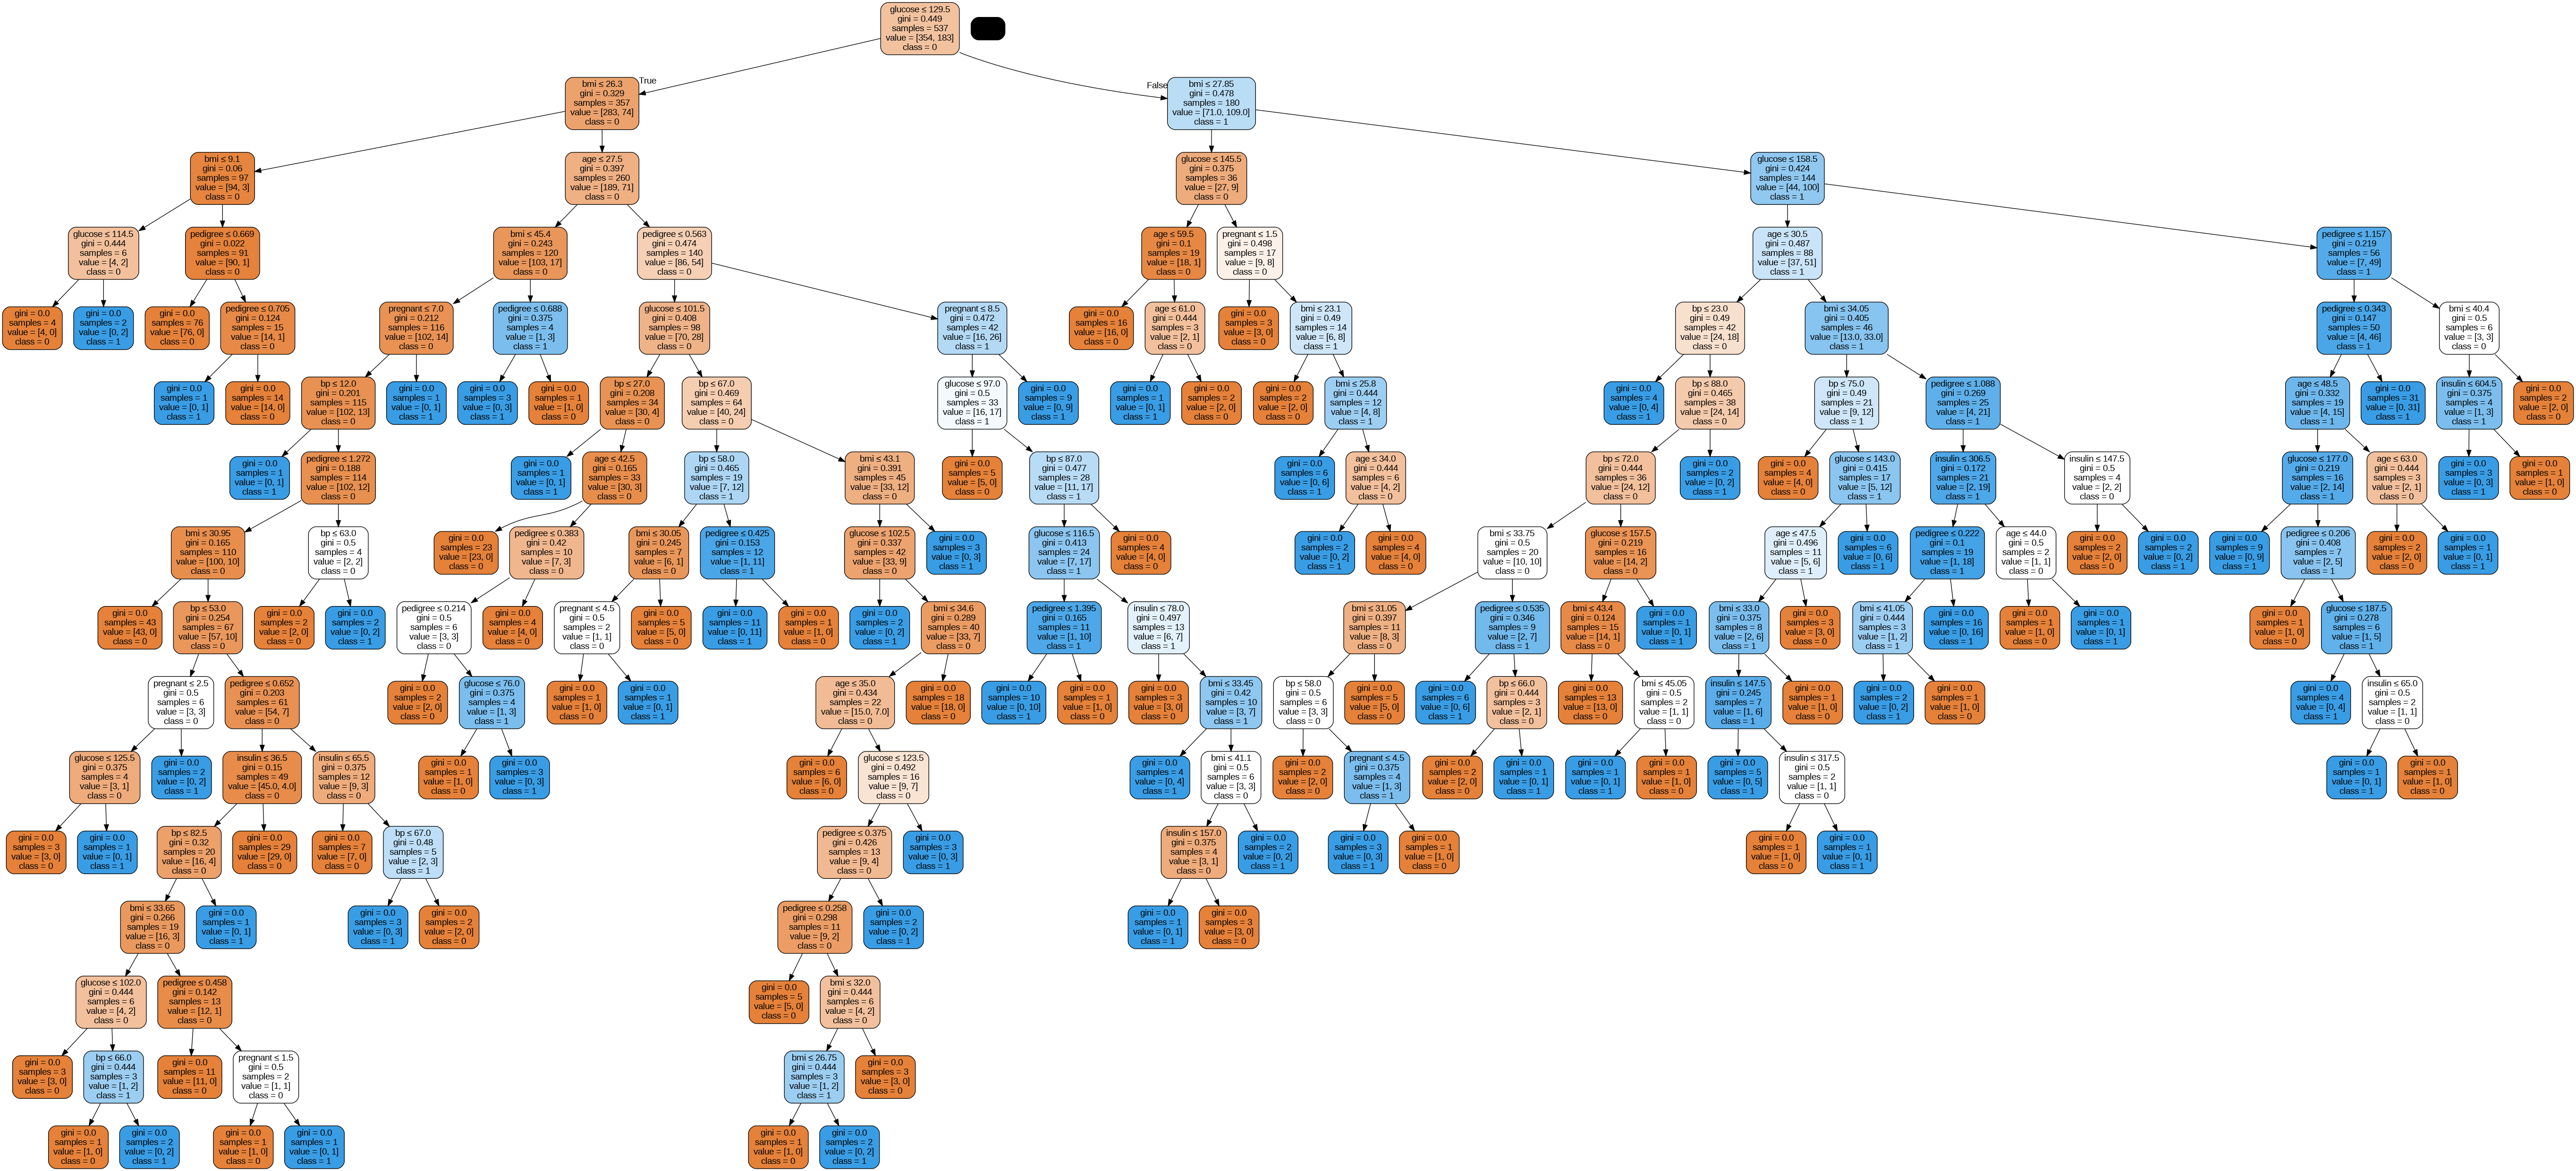

In [ ]:
# Visualizing Decision Tree

from sklearn.tree import export_graphviz
from io import StringIO
from IPython.display import Image
import pydotplus

dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,feature_names = feature_cols,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('diabetes.png')
Image(graph.create_png())

In [ ]:
# INTERPRETATION FOR THIS MODEL
# Glucose levels are the strongest predictor of diabetes in this dataset.
# Higher BMI and Age generally increase the chance of diabetes.
# The model uses multiple features with complex splits, suggesting a nuanced decision boundary.
# The visualization helps understand the rules the model uses to classify a patient as diabetic or not.